# <span style="color:teal"> Lezione 9 </span>
## <span style="color:turquoise"> Esercizio 9.1 </span>
In questo esercizio è stato chiesto di simulare il problema del commesso viaggiatore attraverso l'implementazione di un algoritmo genetico per $N=34$ città disposte in due configurazioni: lungo una circonferenza e disposte casualmente all'interno di un quadrato.

**Il problema del commesso viaggiatore** consiste nel trovare il percorso ottimale che un commesso deve compiere per visitare tutte le $N$ città disponibili, partendo da una città natale e tornando ad essa alla fine del viaggio. La difficoltà del problema risiede nel minimizzare la lunghezza totale del percorso. Se consideriamo la sequenza ordinata di città $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, il percorso ottimale è la permutazione $P$ che minimizza la seguente funzione di costo:
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}| \qquad \text{con}\;\;\vec{x}_{N+1}=\vec{x}_1
$$

Un **algoritmo genetico** è una tecnica di ottimizzazione ispirata all'evoluzione biologica. Si mantiene una popolazione di soluzioni candidate che evolve generazione dopo generazione: gli individui vengono selezionati in base alla loro fitness, combinati tramite crossover e perturbati tramite mutazioni, guidando la popolazione verso la soluzione ottimale. Per implementarlo ho utilizzato un'architettura a classi:
- **Città**: contiene le posizioni $(x, y)$ delle $N$ città in due vector di double. Dispone di due metodi di inizializzazione: `Initialize_circ`, che posiziona le città su una circonferenza unitaria campionando angoli uniformemente in $[0, 2\pi)$, e `Initialize_random`, che le dispone casualmente all'interno del quadrato $[0,1)^2$. Inoltre, la classe ha a disposizione un metodo `Distanza` per calcolare la distanza euclidea tra due città.
  
- **Individuo**: rappresenta un singolo candidato alla soluzione, ovvero una permutazione delle $N$ città codificata come un vector di int. La città 1 è sempre fissata in prima posizione per eliminare la degenerazione ciclica del percorso. La funzione di costo $L^1$ (fitness) viene calcolata dal metodo `Fitness` sommando le distanze euclidee tra città consecutive, chiudendo il percorso. Sono implementate quattro mutazioni:
    - Mutazione 1: scambio di due città casuali nel percorso;
    - Mutazione 2: shift di un blocco di $m$ città di $n$ posizioni;
    - Mutazione 3: scambio di due blocchi contigui di $m$ città;
    - Mutazione 4: inversione dell'ordine di $m$ città consecutive.  
&nbsp;
- **Popolazione**: gestisce un insieme di $M$ individui e guida l'evoluzione generazionale. La selezione avviene tramite una legge potenza $j= int(M \times r^p)+1$. Ad ogni generazione viene applicato il crossover con una certa probabilità: dati due genitori, si sceglie un punto di taglio casuale e ciascun figlio eredita la prima parte dal rispettivo genitore, completando il percorso con le città rimanenti nell'ordine in cui compaiono nell'altro genitore, così da preservare la validità della permutazione. Se invece il crossover non avviene, viene selezionato un singolo individuo. In entrambi i casi, tutti i nuovi individui vengono sottoposti alle mutazioni e la popolazione viene riordinata per fitness.

Per monitorare la convergenza dell'algoritmo, ad ogni generazione vengono salvati il miglior percorso trovato, la fitness del miglior individuo e la fitness media sulla metà migliore della popolazione, così da poterne graficare l'andamento nel corso delle generazioni.  

I parametri utilizzati nella simulazione sono: $N=34$ città, $M=100$ individui, $N_{\text{gen}} = 1000$ generazioni, probabilità di crossover $p_{\text{cross}} = 0.7$, esponente di selezione $p = 2$, che favorisce gli individui con fitness migliore (posizionati davanti) e probabilità uguali per ciascuna mutazione $p_{\text{mut}} = 0.1$.


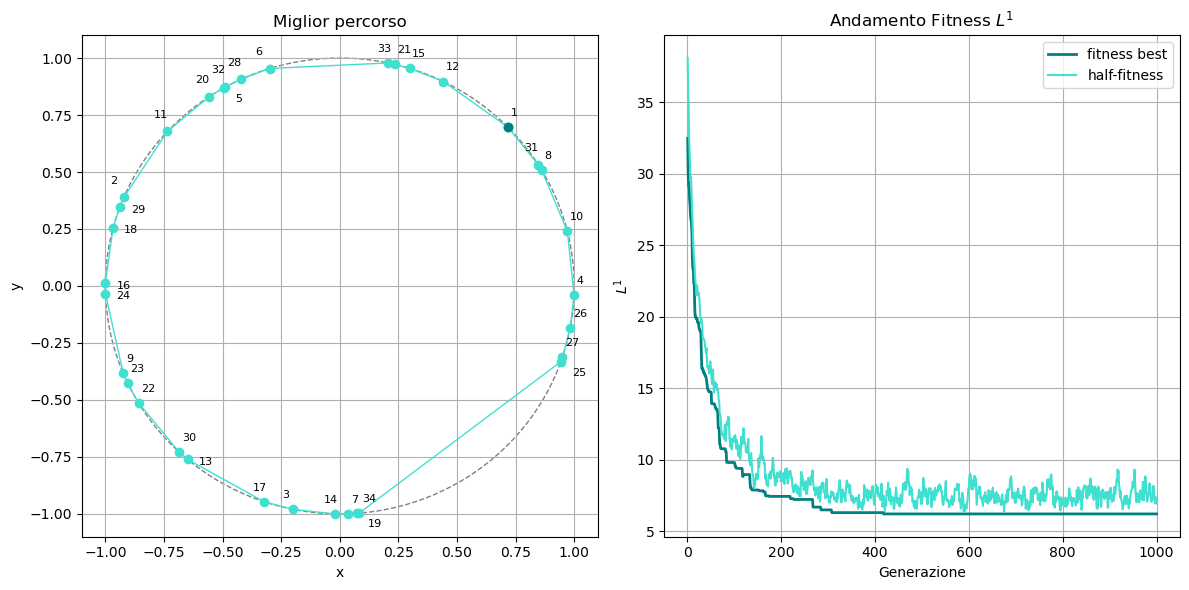

Lunghezza del percorso migliore:  6.20232


In [2]:
# città lungo circonferenza

import numpy as np
import matplotlib.pyplot as plt

# -- carico i punti sulla circonferenza --------------------------------------
data = np.loadtxt("Esercizio9.1/OUTPUT/punti_circ.dat")
x = data[:, 0]
y= data[:, 1]


# -- prendo il best individuo e ordino i punti della circonferenza -------------
with open("Esercizio9.1/OUTPUT/Evoluzione_best_circ.dat") as f:
    ultima_riga = f.readlines()[-1]  
ordine = np.array(ultima_riga.split(), dtype=int)

idx = [i - 1 for i in ordine]
x_ord = x[idx]
y_ord = y[idx]


# -- carico fitness e half-fitness -----------------------------------------------
fitness = np.loadtxt("Esercizio9.1/OUTPUT/Fitness_circ.dat")
step = np.arange(1, len(fitness) + 1)

halffitness = np.loadtxt("Esercizio9.1/OUTPUT/HalfFitness_circ.dat")


# -- indici da posizionare meglio -----------------------------------------------
indici_up = {2, 11, 20, 32, 28, 6, 32, 31}
indici_down = {5, 25, 19}
indici_sx = {17,3,14,33}
indici_dx ={16,24,18,29,13}


# -- theta per disegnare circonferenza -----------------------------------------------------
theta = np.linspace(0, 2 * np.pi, 300)

# -- faccio grafici ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# append aggiunge alla fine il primo elemento così da chiudere il percorso
ax1.plot(np.cos(theta), np.sin(theta), '--', color='grey', lw=1, zorder=0)
ax1.plot(np.append(x_ord, x_ord[0]), np.append(y_ord, y_ord[0]), 'o-', color='turquoise', lw=1)
ax1.plot(x[0], y[0],'o',color='teal',zorder=5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Miglior percorso')
ax1.grid(True)

ax2.plot(step, fitness, '-', color='teal', label='fitness best', lw=2)
ax2.plot(step, halffitness, '-', color='turquoise', label='half-fitness')
ax2.set_xlabel('Generazione')
ax2.set_ylabel('$L^1$')
ax2.set_title('Andamento Fitness $L^1$ ')
ax2.legend()
ax2.grid(True)



# -- sistemo gli indici posizionati male -----------------------------------------------------------------------
for i, (xi, yi) in enumerate(zip(x, y)):
    if i+1 in indici_up:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(-10,10),textcoords='offset points', fontsize=8)

    elif i+1 in indici_down:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(8,-10),textcoords='offset points', fontsize=8)

    elif i+1 in indici_sx:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(-8,8),textcoords='offset points', fontsize=8)

    elif i+1 in indici_dx:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(8,-4),textcoords='offset points', fontsize=8)
    
    else:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(2, 8),textcoords='offset points', fontsize=8)


plt.tight_layout()
plt.show()

print("Lunghezza del percorso migliore: ", fitness[-1])

Nel grafico di sinistra è raffigurato il miglior percorso trovato attraverso le $N=34$ città disposte lungo una circonferenza. Il risultato atteso per questa configurazione è banalmente il percorso che segue la circonferenza stessa, con lunghezza ottimale prossima a $2\pi$. Si può constatare che l'algoritmo lo individua correttamente, raggiungendo un valore di fitness di poco inferiore a $2\pi$.

Nel grafico di destra sono riportati l'andamento della fitness del miglior individuo e della fitness mediata sulla metà migliore della popolazione in funzione del numero di generazioni. Si osserva una rapida decrescita nelle prime generazioni, con convergenza al percorso ottimale poco dopo la $400\, \text{esima}$ generazione. La fitness media della metà migliore continua invece ad oscillare al di sopra del valore ottimale, a indicare che la popolazione mantiene una certa variabilità genetica anche nelle generazioni successive, garantendo di evitare una convergenza prematura verso un minimo locale.

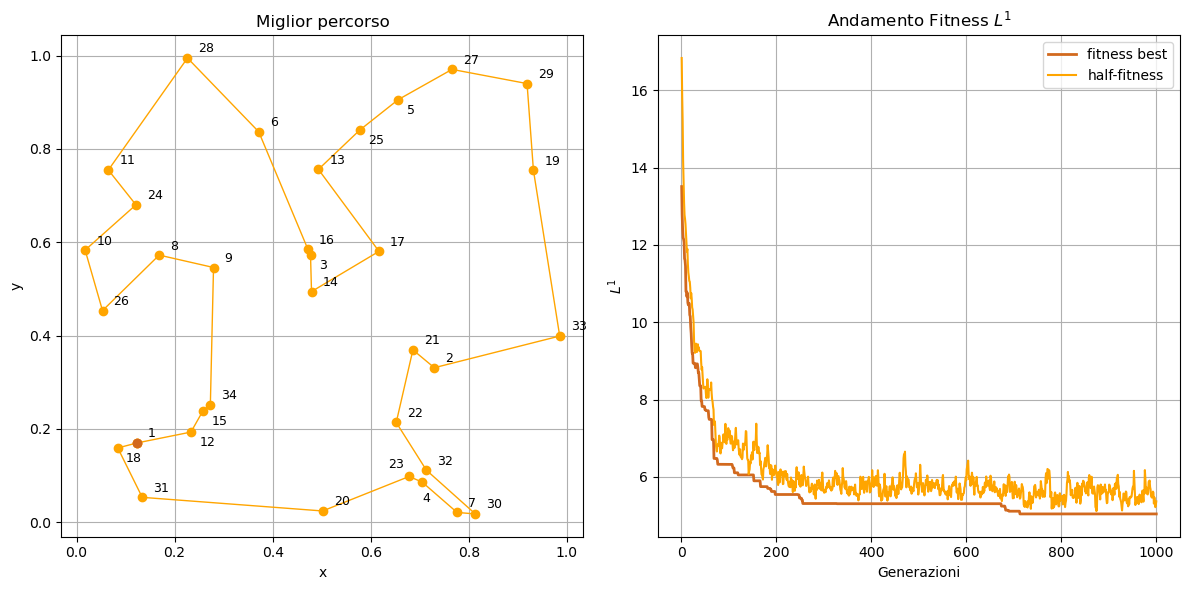

Lunghezza del percorso migliore:  5.0409


In [2]:
# città disposte random

import numpy as np
import matplotlib.pyplot as plt

# -- carico i punti random  --------------------------------------
data = np.loadtxt("Esercizio9.1/OUTPUT/punti_random.dat")
x = data[:, 0]
y= data[:, 1]


# -- prendo il best individuo e ordino i punti random -------------
with open("Esercizio9.1/OUTPUT/Evoluzione_best_random.dat") as f:
    ultima_riga = f.readlines()[-1]  
ordine = np.array(ultima_riga.split(), dtype=int)

idx = [i - 1 for i in ordine]
x_ord = x[idx]
y_ord = y[idx]

# -- carico fitness e half-fitness -----------------------------------------------
fitness = np.loadtxt("Esercizio9.1/OUTPUT/Fitness_random.dat")
step = np.arange(1, len(fitness) + 1)

halffitness = np.loadtxt("Esercizio9.1/OUTPUT/HalfFitness_random.dat")


# -- indici da posizionare meglio -----------------------------------------------
indici_storti = {3, 5, 12, 15, 18, 25}

# -- faccio grafici ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(np.append(x_ord, x_ord[0]), np.append(y_ord, y_ord[0]), 'o-', color='orange', lw=1)
ax1.plot(x[0], y[0],'o',color='chocolate',zorder=5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Miglior percorso')
ax1.grid(True)

ax2.plot(step, fitness, '-', color='chocolate', label='fitness best', lw=2)
ax2.plot(step, halffitness, '-', color='orange', label='half-fitness')
ax2.set_xlabel('Generazioni')
ax2.set_ylabel('$L^1$')
ax2.set_title('Andamento Fitness $L^1$')
ax2.legend()
ax2.grid(True)


# -- sistemo gli indici posizionati male -----------------------------------------------------------------------
for i, (xi, yi) in enumerate(zip(x, y)):
    if i+1 in indici_storti:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(6,-10),textcoords='offset points', fontsize=9)

    elif i+1==23:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(-15,6),textcoords='offset points', fontsize=9)

    elif i+1==4:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(0,-14),textcoords='offset points', fontsize=9)
    
    else:
        ax1.annotate(f'{i+1}', xy=(xi, yi), xytext=(8, 4),textcoords='offset points', fontsize=9)


plt.tight_layout()
plt.show()

print("Lunghezza del percorso migliore: ", fitness[-1])

Nel grafico di sinistra è raffigurato il miglior percorso trovato attraverso le $N=34$ città disposte casualmente all'interno del quadrato $[0,1)^2$. A differenza del caso precedente, non esiste una soluzione banalmente attesa, ma un buon indicatore qualitativo è l'assenza di incroci nel percorso, poiché un percorso ottimale non dovrebbe mai auto-intersecarsi. Il percorso trovato non ne presenta, suggerendoci che l'algoritmo abbia individuato una buona soluzione, con una lunghezza finale $L^1 \approx 5.04$. Tuttavia non possiamo avere la certezza assoluta di aver individuato il minimo globale del problema.

Nel grafico di destra sono riportati l'andamento della fitness del miglior individuo e della fitness mediata sulla metà migliore della popolazione in funzione del numero di generazioni. Si osserva una rapida decrescita nelle prime generazioni, con convergenza al percorso ottimale poco dopo la $700\, \text{esima}$ generazione. La fitness media della metà migliore continua invece ad oscillare al di sopra del valore ottimale, a indicare che la popolazione mantiene una certa variabilità genetica anche nelle generazioni successive, garantendo di evitare una convergenza prematura verso un minimo locale.

Infine, per rendere evidente la dinamica evolutiva dell'algoritmo in modo intuitivo, vengono riportate due gif animate che mostrano come il miglior percorso si trasformi generazione dopo generazione, per entrambe le configurazioni di città considerate.

In [1]:
# codice per visualizzare gif
from IPython.display import display
import ipywidgets as widgets

gif1 = open("evoluzione_percorso_circonferenza.gif", "rb").read()
gif2 = open("evoluzione_percorso_random.gif", "rb").read()

img1 = widgets.Image(value=gif1, format='gif', layout=widgets.Layout(width='450px', height='450px'))
img2 = widgets.Image(value=gif2, format='gif', layout=widgets.Layout(width='450px', height='450px'))

widgets.HBox([img1, img2])